In [65]:
%pip install pandas numpy openpyxl
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\prala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\prala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 330.3 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 469.7 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 500.2 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     --- ------------------------------------ 10.2/127.4 kB ? eta -:--:--
     ----------- ------------------------- 41.0/127.4 kB 653.6 kB/s eta 0:00:01
     ----------------------- ------------- 81.9/127.4 kB 770.8 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/127.4 kB 751.6 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/127.4 kB 751.6 kB/s eta 0:00:01
     ------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\prala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [48]:
# Financial Fraud Detection
# Day 1 - Dataset Inspection

import os
import pandas as pd
import numpy as np
import sklearn

print("scikit-learn version:", sklearn.__version__)
print("Environment ready.")

scikit-learn version: 1.9.1
Environment ready.


In [29]:
# Dataset directory

DATA_DIR = "../data/raw"

print("Dataset directory:", os.path.abspath(DATA_DIR))

Dataset directory: c:\Users\prala\Financial-Fraud-Detection\data\raw


In [30]:
# Check files available in the raw dataset directory

files = os.listdir(DATA_DIR)

print(f"Total files found: {len(files)}")
print()

for file in files:
    print(file)

Total files found: 11

Base.csv
credit_card_fraud_dataset.csv
financial_fraud_detection_dataset.csv
Fraud Detection.xlsx
PS_20174392719_1491204439457_log.csv
synthetic_fraud_dataset1.csv
Variant I.csv
Variant II.csv
Variant III.csv
Variant IV.csv
Variant V.csv


In [31]:
# Basic inspection of all datasets

for file in sorted(os.listdir(DATA_DIR)):
    
    file_path = os.path.join(DATA_DIR, file)
    
    print("=" * 80)
    print(f"FILE: {file}")
    print("=" * 80)
    
    try:
        if file.lower().endswith(".csv"):
            df = pd.read_csv(file_path)
        
        elif file.lower().endswith(".xlsx"):
            df = pd.read_excel(file_path)
        
        else:
            print("Unsupported file type")
            continue
        
        print(f"Rows    : {df.shape[0]:,}")
        print(f"Columns : {df.shape[1]:,}")
        print("\nColumn names:")
        print(list(df.columns))
        
        print("\nFirst 3 rows:")
        display(df.head(3))
        
        print("\nData types:")
        print(df.dtypes)
        
        print("\nMissing values:")
        print(df.isnull().sum())
        
        print("\nDuplicate rows:", df.duplicated().sum())
        
    except Exception as e:
        print(f"ERROR: {e}")
    
    print("\n")

FILE: Base.csv
Rows    : 1,000,000
Columns : 32

Column names:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

First 3 rows:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0



Data types:
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                            str
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                       str
credit_risk_score                     int64
email_is_free                         int64
housing_status                          str
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards    

,step,type,branch,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,unusuallogin,isFlaggedFraud,Acct type,Date of transaction,Time of day,isFraud,Column1,isFraud - Copy,DayOfWeek,DayOfWeek(new)
0,7,PAYMENT,Espana,1526.50,C1908839976,0.0,0.0,M1304522697,0.0,0.0,7,0,Savings,2018-01-03,Afternoon,Safe,7168,0.0,3.0,Wednesday
1,7,PAYMENT,Honduras,1620.17,C70432899,0.0,0.0,M252297858,0.0,0.0,2,0,Savings,2018-01-05,Night,Safe,7211,0.0,5.0,Friday
2,7,PAYMENT,Indonesia,5689.82,C332151172,0.0,0.0,M1430674428,0.0,0.0,3,0,Savings,2018-01-07,Morning,Safe,7268,0.0,7.0,Sunday



Data types:
step                            int64
type                              str
branch                            str
amount                        float64
nameOrig                          str
oldbalanceOrg                 float64
newbalanceOrig                float64
nameDest                          str
oldbalanceDest                float64
newbalanceDest                float64
unusuallogin                    int64
isFlaggedFraud                  int64
Acct type                         str
Date of transaction    datetime64[us]
Time of day                       str
isFraud                           str
Column1                         int64
isFraud - Copy                float64
DayOfWeek                     float64
DayOfWeek(new)                    str
dtype: object

Missing values:
step                    0
type                    4
branch                  0
amount                  2
nameOrig                6
oldbalanceOrg           2
newbalanceOrig          0
nameDest      

...


Data types:
TransactionID        int64
TransactionDate        str
Amount             float64
MerchantID           int64
TransactionType        str
Location               str
IsFraud              int64
dtype: object

Missing values:
TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64

Duplicate rows: 0


FILE: financial_fraud_detection_dataset.csv
Rows    : 5,000
Columns : 14

Column names:
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent']

First 3 rows:


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0



Data types:
Transaction_ID               str
Customer_ID                  str
Transaction_Date             str
Transaction_Amount       float64
Merchant_Category            str
Payment_Method               str
Device_Type                  str
Location                     str
Is_International           int64
Previous_Transactions      int64
Average_Spend            float64
Account_Age_Days           int64
Suspicious_Keyword           str
Fraudulent                 int64
dtype: object

Missing values:
Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

Duplicate rows: 0


FILE: synthetic_fraud_dataset1.csv
Rows    : 50,000
Columns : 14

Column names:
['

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1



Data types:
Transaction_ID                      str
User_ID                             str
Transaction_Amount              float64
Transaction_Type                    str
Date                                str
Account_Balance                 float64
Device_Type                         str
Location                            str
Merchant_Category                   str
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Card_Type                           str
Card_Age                          int64
Fraud_Label                       int64
dtype: object

Missing values:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type             

In [32]:
# Compact comparison of all datasets

dataset_summary = []

for file in sorted(os.listdir(DATA_DIR)):
    
    file_path = os.path.join(DATA_DIR, file)
    
    try:
        if file.lower().endswith(".csv"):
            df = pd.read_csv(file_path)
        
        elif file.lower().endswith(".xlsx"):
            df = pd.read_excel(file_path)
        
        else:
            continue
        
        # Find possible fraud/target columns
        target_candidates = [
            col for col in df.columns
            if any(word in col.lower() for word in ["fraud", "label", "target"])
        ]
        
        dataset_summary.append({
            "File": file,
            "Rows": df.shape[0],
            "Columns": df.shape[1],
            "Missing Values": int(df.isnull().sum().sum()),
            "Duplicate Rows": int(df.duplicated().sum()),
            "Possible Target Columns": ", ".join(target_candidates) if target_candidates else "None"
        })
        
    except Exception as e:
        dataset_summary.append({
            "File": file,
            "Rows": "ERROR",
            "Columns": "ERROR",
            "Missing Values": "ERROR",
            "Duplicate Rows": "ERROR",
            "Possible Target Columns": str(e)
        })

summary_df = pd.DataFrame(dataset_summary)

display(summary_df)

,File,Rows,Columns,Missing Values,Duplicate Rows,Possible Target Columns
0,Base.csv,1000000,32,0,0,"fraud_bool, device_fraud_count"
1,Fraud Detection.xlsx,10127,20,58,0,"isFlaggedFraud, isFraud, isFraud - Copy"
2,PS_20174392719_1491204439457_log.csv,6362620,11,0,0,"isFraud, isFlaggedFraud"
3,Variant I.csv,1000000,32,0,0,"fraud_bool, device_fraud_count"
4,Variant II.csv,1000000,32,0,0,"fraud_bool, device_fraud_count"
5,Variant III.csv,1000000,34,0,0,"fraud_bool, device_fraud_count"
6,Variant IV.csv,1000000,32,0,0,"fraud_bool, device_fraud_count"
7,Variant V.csv,1000000,34,0,0,"fraud_bool, device_fraud_count"
8,credit_card_fraud_dataset.csv,100000,7,0,0,IsFraud
9,financial_fraud_detection_dataset.csv,5000,14,0,0,Fraudulent


In [33]:
# Target distribution for all datasets

target_columns = {
    "Base.csv": "fraud_bool",
    "Variant I.csv": "fraud_bool",
    "Variant II.csv": "fraud_bool",
    "Variant III.csv": "fraud_bool",
    "Variant IV.csv": "fraud_bool",
    "Variant V.csv": "fraud_bool",
    "PS_20174392719_1491204439457_log.csv": "isFraud",
    "credit_card_fraud_dataset.csv": "IsFraud",
    "financial_fraud_detection_dataset.csv": "Fraudulent",
    "synthetic_fraud_dataset1.csv": "Fraud_Label",
    "Fraud Detection.xlsx": "isFraud"
}

target_summary = []

for file, target in target_columns.items():

    file_path = os.path.join(DATA_DIR, file)

    if file.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    elif file.lower().endswith(".xlsx"):
        df = pd.read_excel(file_path)

    counts = df[target].value_counts(dropna=False)
    percentages = df[target].value_counts(normalize=True, dropna=False) * 100

    for value in counts.index:
        target_summary.append({
            "File": file,
            "Target": target,
            "Class": value,
            "Count": counts[value],
            "Percentage": round(percentages[value], 2)
        })

target_distribution_df = pd.DataFrame(target_summary)

display(target_distribution_df)

,File,Target,Class,Count,Percentage
0,Base.csv,fraud_bool,0,988971,98.90
1,Base.csv,fraud_bool,1,11029,1.10
2,Variant I.csv,fraud_bool,0,988971,98.90
3,Variant I.csv,fraud_bool,1,11029,1.10
4,Variant II.csv,fraud_bool,0,988971,98.90
5,Variant II.csv,fraud_bool,1,11029,1.10
6,Variant III.csv,fraud_bool,0,988970,98.90
7,Variant III.csv,fraud_bool,1,11030,1.10
8,Variant IV.csv,fraud_bool,0,988970,98.90
9,Variant IV.csv,fraud_bool,1,11030,1.10


In [34]:
# Compare Base dataset with its variants

variant_files = [
    "Base.csv",
    "Variant I.csv",
    "Variant II.csv",
    "Variant III.csv",
    "Variant IV.csv",
    "Variant V.csv"
]

variant_comparison = []

for file in variant_files:
    
    file_path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(file_path)
    
    variant_comparison.append({
        "File": file,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Column Names": list(df.columns),
        "Fraud Cases": int(df["fraud_bool"].sum()),
        "Fraud Rate (%)": round(df["fraud_bool"].mean() * 100, 2)
    })

variant_comparison_df = pd.DataFrame(variant_comparison)

display(variant_comparison_df)

,File,Rows,Columns,Column Names,Fraud Cases,Fraud Rate (%)
0,Base.csv,1000000,32,"[fraud_bool, income, name_email_similarity, pr...",11029,1.1
1,Variant I.csv,1000000,32,"[fraud_bool, income, name_email_similarity, pr...",11029,1.1
2,Variant II.csv,1000000,32,"[fraud_bool, income, name_email_similarity, pr...",11029,1.1
3,Variant III.csv,1000000,34,"[fraud_bool, income, name_email_similarity, pr...",11030,1.1
4,Variant IV.csv,1000000,32,"[fraud_bool, income, name_email_similarity, pr...",11030,1.1
5,Variant V.csv,1000000,34,"[fraud_bool, income, name_email_similarity, pr...",11030,1.1


In [35]:
# Compare columns across Base and Variants

variant_files = [
    "Base.csv",
    "Variant I.csv",
    "Variant II.csv",
    "Variant III.csv",
    "Variant IV.csv",
    "Variant V.csv"
]

for file in variant_files:
    df = pd.read_csv(os.path.join(DATA_DIR, file), nrows=5)
    
    print("=" * 80)
    print(file)
    print("=" * 80)
    print("Number of columns:", len(df.columns))
    print("Columns:")
    print(list(df.columns))
    print()

Base.csv
Number of columns: 32
Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

Variant I.csv
Number of columns: 32
Columns:
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branc

In [36]:
# Selected dataset: Base.csv
# Feature overview

BASE_FILE = "Base.csv"
TARGET = "fraud_bool"

base_df = pd.read_csv(os.path.join(DATA_DIR, BASE_FILE))

print("Dataset:", BASE_FILE)
print("Shape:", base_df.shape)
print("Target:", TARGET)
print()

print("Data types:")
print(base_df.dtypes)

print("\nNumerical columns:")
print(list(base_df.select_dtypes(include=np.number).columns))

print("\nCategorical columns:")
print(list(base_df.select_dtypes(include=["object", "category"]).columns))

Dataset: Base.csv
Shape: (1000000, 32)
Target: fraud_bool

Data types:
fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                            str
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                       str
credit_risk_score                     int64
email_is_free                         int64
housing_status                          str
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_

C:\Users\prala\AppData\Local\Temp\ipykernel_816\1614842116.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(list(base_df.select_dtypes(include=["object", "category"]).columns))


In [37]:
# Inspect categorical feature values

categorical_columns = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

for col in categorical_columns:
    print("=" * 60)
    print(f"Column: {col}")
    print(f"Unique values: {base_df[col].nunique()}")
    print("Values:")
    print(base_df[col].value_counts(dropna=False))
    print()

Column: payment_type
Unique values: 5
Values:
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289
Name: count, dtype: int64

Column: employment_status
Unique values: 7
Values:
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453
Name: count, dtype: int64

Column: housing_status
Unique values: 7
Values:
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252
Name: count, dtype: int64

Column: source
Unique values: 2
Values:
source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64

Column: device_os
Unique values: 5
Values:
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228
Name: count, dtype: int64



In [38]:
# Categorical feature summary

categorical_summary = []

for col in categorical_columns:
    categorical_summary.append({
        "Feature": col,
        "Unique Values": base_df[col].nunique(),
        "Missing Values": base_df[col].isnull().sum()
    })

categorical_summary_df = pd.DataFrame(categorical_summary)

display(categorical_summary_df)

,Feature,Unique Values,Missing Values
0,payment_type,5,0
1,employment_status,7,0
2,housing_status,7,0
3,source,2,0
4,device_os,5,0


In [39]:
# Numerical feature overview

numerical_columns = base_df.select_dtypes(include=np.number).columns.tolist()

numerical_summary = pd.DataFrame({
    "Feature": numerical_columns,
    "Unique Values": [base_df[col].nunique() for col in numerical_columns],
    "Min": [base_df[col].min() for col in numerical_columns],
    "Max": [base_df[col].max() for col in numerical_columns],
    "Mean": [base_df[col].mean() for col in numerical_columns],
    "Missing Values": [base_df[col].isnull().sum() for col in numerical_columns]
})

display(numerical_summary)

,Feature,Unique Values,Min,Max,Mean,Missing Values
0,fraud_bool,2,0.000000e+00,1.000000,0.011029,0
1,income,9,1.000000e-01,0.900000,0.562696,0
2,name_email_similarity,998861,1.434550e-06,0.999999,0.493694,0
3,prev_address_months_count,374,-1.000000e+00,383.000000,16.718568,0
4,current_address_months_count,423,-1.000000e+00,428.000000,86.587867,0
5,customer_age,9,1.000000e+01,90.000000,33.689080,0
6,days_since_request,989330,4.036860e-09,78.456904,1.025705,0
7,intended_balcon_amount,994971,-1.553055e+01,112.956928,8.661499,0
8,zip_count_4w,6306,1.000000e+00,6700.000000,1572.692049,0
9,velocity_6h,998687,-1.706031e+02,16715.565404,5665.296605,0


In [40]:
# Check binary features and their relationship with fraud

binary_columns = [
    col for col in numerical_columns
    if base_df[col].nunique() == 2 and col != TARGET
]

print("Binary features:")
print(binary_columns)
print()

for col in binary_columns:
    print("=" * 60)
    print(f"Feature: {col}")
    
    fraud_rate = base_df.groupby(col)[TARGET].mean() * 100
    
    print("Fraud rate by value:")
    print(fraud_rate)
    print()
    
print("=" * 60)
print("Constant feature check:")
print("device_fraud_count unique values:", base_df["device_fraud_count"].unique())

Binary features:
['email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards', 'foreign_request', 'keep_alive_session']

Feature: email_is_free
Fraud rate by value:
email_is_free
0    0.795126
1    1.375956
Name: fraud_bool, dtype: float64

Feature: phone_home_valid
Fraud rate by value:
phone_home_valid
0    1.413223
1    0.669181
Name: fraud_bool, dtype: float64

Feature: phone_mobile_valid
Fraud rate by value:
phone_mobile_valid
0    1.493782
1    1.054429
Name: fraud_bool, dtype: float64

Feature: has_other_cards
Fraud rate by value:
has_other_cards
0    1.299594
1    0.417511
Name: fraud_bool, dtype: float64

Feature: foreign_request
Fraud rate by value:
foreign_request
0    1.074523
1    2.198716
Name: fraud_bool, dtype: float64

Feature: keep_alive_session
Fraud rate by value:
keep_alive_session
0    1.716333
1    0.653093
Name: fraud_bool, dtype: float64

Constant feature check:
device_fraud_count unique values: [0]


In [41]:
# Fraud rate for the remaining binary features

for col in ["has_other_cards", "foreign_request", "keep_alive_session"]:
    print("=" * 60)
    print(f"Feature: {col}")
    
    result = base_df.groupby(col)[TARGET].agg(
        Count="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
    
    result["Fraud_Rate"] = result["Fraud_Rate"] * 100
    
    display(result)

Feature: has_other_cards


,Count,Fraud_Count,Fraud_Rate
has_other_cards,,,
0,777012,10098,1.299594
1,222988,931,0.417511


Feature: foreign_request


,Count,Fraud_Count,Fraud_Rate
foreign_request,,,
0,974758,10474,1.074523
1,25242,555,2.198716


Feature: keep_alive_session


,Count,Fraud_Count,Fraud_Rate
keep_alive_session,,,
0,423053,7261,1.716333
1,576947,3768,0.653093


In [42]:
# ============================================================
# DAY 2 - DATA PREPARATION
# Step 1: Load selected dataset
# ============================================================

BASE_FILE = "Base.csv"
TARGET = "fraud_bool"

base_df = pd.read_csv(os.path.join(DATA_DIR, BASE_FILE))

print("Dataset loaded successfully.")
print("Dataset:", BASE_FILE)
print("Shape:", base_df.shape)
print("Target:", TARGET)

Dataset loaded successfully.
Dataset: Base.csv
Shape: (1000000, 32)
Target: fraud_bool


In [43]:
# ============================================================
# Day 2 - Step 2: Separate Features and Target
# ============================================================

X = base_df.drop(columns=[TARGET])
y = base_df[TARGET]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Features (X): (1000000, 31)
Target (y): (1000000,)

Target distribution:
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Target percentage:
fraud_bool
0    98.9
1     1.1
Name: proportion, dtype: float64


In [44]:
# ============================================================
# Day 2 - Step 3: Remove Constant Features
# ============================================================

# Check features with only one unique value
constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
['device_fraud_count']


In [45]:
# ============================================================
# Day 2 - Step 4: Remove Constant Features
# ============================================================

X = X.drop(columns=constant_features)

print("Constant features removed:", constant_features)
print("Features remaining:", X.shape[1])
print("X shape:", X.shape)

Constant features removed: ['device_fraud_count']
Features remaining: 30
X shape: (1000000, 30)


In [49]:
# ============================================================
# Day 2 - Step 5: Stratified Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (800000, 30)
y_train: (800000,)

Test set:
X_test: (200000, 30)
y_test: (200000,)


In [50]:
# ============================================================
# Day 2 - Step 6: Verify Stratified Split
# ============================================================

print("Training target distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training target distribution:
fraud_bool
0    791177
1      8823
Name: count, dtype: int64
fraud_bool
0    98.9
1     1.1
Name: proportion, dtype: float64

Test target distribution:
fraud_bool
0    197794
1      2206
Name: count, dtype: int64
fraud_bool
0    98.9
1     1.1
Name: proportion, dtype: float64


In [51]:
# ============================================================
# Day 2 - Step 7: Check Missing Values
# ============================================================

missing_values = X_train.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Features with missing values:")
print(missing_values)

print("\nTotal missing values:", X_train.isnull().sum().sum())

Features with missing values:
Series([], dtype: int64)

Total missing values: 0


In [53]:
# ============================================================
# Day 2 - Step 8: Check -1 Values
# ============================================================

minus_one_counts = (X_train == -1).sum()

minus_one_counts = minus_one_counts[minus_one_counts > 0].sort_values(
    ascending=False
)

print("Features containing -1:")
print(minus_one_counts)

print("\nTotal -1 values:", (X_train == -1).sum().sum())

Features containing -1:
prev_address_months_count       570525
bank_months_count               202604
current_address_months_count      3391
session_length_in_minutes         1623
credit_risk_score                  388
device_distinct_emails_8w          290
dtype: int64

Total -1 values: 778821


In [54]:
# ============================================================
# Day 2 - Step 9: Analyze -1 Values and Fraud Rate
# ============================================================

minus_one_features = [
    "prev_address_months_count",
    "bank_months_count",
    "current_address_months_count",
    "session_length_in_minutes",
    "credit_risk_score",
    "device_distinct_emails_8w"
]

for col in minus_one_features:
    print(f"\n{'=' * 60}")
    print(f"Feature: {col}")
    
    minus_one_rate = y_train[X_train[col] == -1].mean() * 100
    normal_rate = y_train[X_train[col] != -1].mean() * 100
    
    print(f"Rows with -1:     {(X_train[col] == -1).sum():,}")
    print(f"Fraud rate (-1):  {minus_one_rate:.2f}%")
    print(f"Fraud rate (!=-1): {normal_rate:.2f}%")


Feature: prev_address_months_count
Rows with -1:     570,525
Fraud rate (-1):  1.42%
Fraud rate (!=-1): 0.32%

Feature: bank_months_count
Rows with -1:     202,604
Fraud rate (-1):  1.63%
Fraud rate (!=-1): 0.92%

Feature: current_address_months_count
Rows with -1:     3,391
Fraud rate (-1):  0.29%
Fraud rate (!=-1): 1.11%

Feature: session_length_in_minutes
Rows with -1:     1,623
Fraud rate (-1):  0.99%
Fraud rate (!=-1): 1.10%

Feature: credit_risk_score
Rows with -1:     388
Fraud rate (-1):  0.00%
Fraud rate (!=-1): 1.10%

Feature: device_distinct_emails_8w
Rows with -1:     290
Fraud rate (-1):  1.38%
Fraud rate (!=-1): 1.10%


In [55]:
# ============================================================
# Day 2 - Step 9A: Compact -1 Analysis
# ============================================================

for col in minus_one_features:
    mask = X_train[col] == -1
    
    print(
        f"{col:35} | "
        f"-1 rows: {mask.sum():7,} | "
        f"Fraud (-1): {y_train[mask].mean()*100:5.2f}% | "
        f"Fraud (!=-1): {y_train[~mask].mean()*100:5.2f}%"
    )

prev_address_months_count           | -1 rows: 570,525 | Fraud (-1):  1.42% | Fraud (!=-1):  0.32%
bank_months_count                   | -1 rows: 202,604 | Fraud (-1):  1.63% | Fraud (!=-1):  0.92%
current_address_months_count        | -1 rows:   3,391 | Fraud (-1):  0.29% | Fraud (!=-1):  1.11%
session_length_in_minutes           | -1 rows:   1,623 | Fraud (-1):  0.99% | Fraud (!=-1):  1.10%
credit_risk_score                   | -1 rows:     388 | Fraud (-1):  0.00% | Fraud (!=-1):  1.10%
device_distinct_emails_8w           | -1 rows:     290 | Fraud (-1):  1.38% | Fraud (!=-1):  1.10%


In [56]:
# ============================================================
# Day 2 - Step 10: Check Duplicate Rows
# ============================================================

print("Duplicate rows in X_train:", X_train.duplicated().sum())
print("Duplicate rows in X_test:", X_test.duplicated().sum())

Duplicate rows in X_train: 0
Duplicate rows in X_test: 0


In [57]:
# ============================================================
# Day 2 - Step 11: Inspect Categorical Features
# ============================================================

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

for col in categorical_features:
    print(f"\n{col}:")
    print("Unique values:", X_train[col].nunique())
    print("Values:", X_train[col].unique())

C:\Users\prala\AppData\Local\Temp\ipykernel_816\261424041.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Categorical features:
['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

Number of categorical features: 5

payment_type:
Unique values: 5
Values: <StringArray>
['AA', 'AB', 'AC', 'AD', 'AE']
Length: 5, dtype: str

employment_status:
Unique values: 7
Values: <StringArray>
['CA', 'CC', 'CB', 'CF', 'CD', 'CE', 'CG']
Length: 7, dtype: str

housing_status:
Unique values: 7
Values: <StringArray>
['BC', 'BD', 'BE', 'BB', 'BA', 'BF', 'BG']
Length: 7, dtype: str

source:
Unique values: 2
Values: <StringArray>
['INTERNET', 'TELEAPP']
Length: 2, dtype: str

device_os:
Unique values: 5
Values: <StringArray>
['linux', 'other', 'windows', 'macintosh', 'x11']
Length: 5, dtype: str


In [58]:
# ============================================================
# Day 2 - Step 12: Check Unseen Categories
# ============================================================

print("Checking categorical values in test set...\n")

for col in categorical_features:
    train_values = set(X_train[col].unique())
    test_values = set(X_test[col].unique())
    
    unseen_values = test_values - train_values
    
    print(f"{col}:")
    print("  Training categories:", len(train_values))
    print("  Test categories:", len(test_values))
    print("  Unseen test categories:", unseen_values)

Checking categorical values in test set...

payment_type:
  Training categories: 5
  Test categories: 5
  Unseen test categories: set()
employment_status:
  Training categories: 7
  Test categories: 7
  Unseen test categories: set()
housing_status:
  Training categories: 7
  Test categories: 7
  Unseen test categories: set()
source:
  Training categories: 2
  Test categories: 2
  Unseen test categories: set()
device_os:
  Training categories: 5
  Test categories: 5
  Unseen test categories: set()


In [59]:
# ============================================================
# Day 2 - Step 13: One-Hot Encode Categorical Features
# ============================================================

from sklearn.preprocessing import OneHotEncoder

# Create encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit only on training data
encoder.fit(X_train[categorical_features])

# Transform categorical features
X_train_encoded = encoder.transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

print("Categorical encoding completed.")

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Categorical encoding completed.
Encoded training shape: (800000, 26)
Encoded test shape: (200000, 26)


In [60]:
# ============================================================
# Day 2 - Step 14: Combine Numerical and Encoded Features
# ============================================================

# Identify numerical features
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

# Extract numerical data
X_train_numeric = X_train[numerical_features]
X_test_numeric = X_test[numerical_features]

# Convert encoded arrays to DataFrames
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

# Combine numerical + encoded categorical features
X_train_processed = pd.concat(
    [X_train_numeric, X_train_encoded_df],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_numeric, X_test_encoded_df],
    axis=1
)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Number of numerical features: 25
Numerical features:
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'month']

Processed training shape: (800000, 51)
Processed test shape: (200000, 51)


In [61]:
# ============================================================
# Day 2 - Step 15: Final Processed Data Check
# ============================================================

print("Missing values:")
print("X_train_processed:", X_train_processed.isnull().sum().sum())
print("X_test_processed:", X_test_processed.isnull().sum().sum())

print("\nInfinite values:")
print(
    "X_train_processed:",
    np.isinf(X_train_processed.to_numpy()).sum()
)

print(
    "X_test_processed:",
    np.isinf(X_test_processed.to_numpy()).sum()
)

print("\nFinal shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Missing values:
X_train_processed: 0
X_test_processed: 0

Infinite values:
X_train_processed: 0
X_test_processed: 0

Final shapes:
X_train_processed: (800000, 51)
X_test_processed: (200000, 51)
y_train: (800000,)
y_test: (200000,)


# Day 3 - Exploratory Data Analysis (EDA)

The objective of this analysis is to understand fraud patterns,
class imbalance, feature distributions, and relationships between
the input features and the fraud target.

EDA will primarily be performed on the training data to avoid
using the test set for exploratory decisions.

In [63]:
# ============================================================
# Day 3 - Step 1: EDA Dataset Overview
# ============================================================

print("Training dataset shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nFraud distribution:")
print(y_train.value_counts())

print("\nFraud percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training dataset shape: (800000, 30)
Training target shape: (800000,)

Fraud distribution:
fraud_bool
0    791177
1      8823
Name: count, dtype: int64

Fraud percentage:
fraud_bool
0    98.9
1     1.1
Name: proportion, dtype: float64


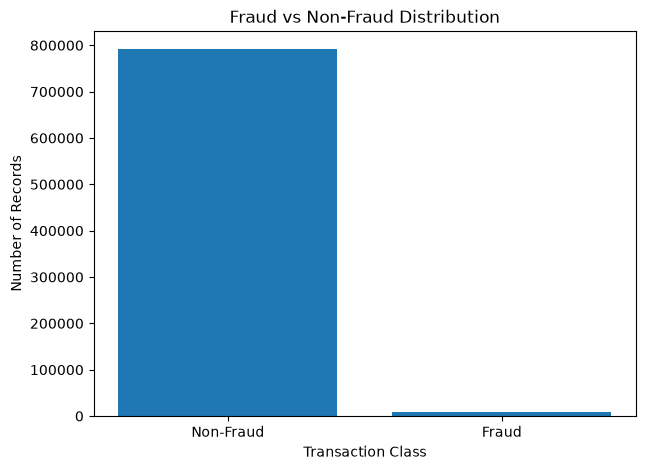

In [67]:
# ============================================================
# Day 3 - Step 2: Fraud vs Non-Fraud Distribution
# ============================================================

import matplotlib.pyplot as plt

fraud_counts = y_train.value_counts().sort_index()

labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(7, 5))
plt.bar(labels, fraud_counts.values)

plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Records")

plt.show()

In [68]:
# ============================================================
# Day 3 - Step 3: Fraud Rate by Categorical Features
# ============================================================

for col in categorical_features:
    fraud_rate = (
        pd.DataFrame({
            col: X_train[col],
            "fraud": y_train.values
        })
        .groupby(col)["fraud"]
        .agg(["count", "sum", "mean"])
    )

    fraud_rate["fraud_rate_%"] = fraud_rate["mean"] * 100

    print(f"\n{'='*60}")
    print(f"Feature: {col}")
    print(f"{'='*60}")

    print(
        fraud_rate[
            ["count", "sum", "fraud_rate_%"]
        ].sort_values("fraud_rate_%", ascending=False).round(2)
    )


Feature: payment_type
               count   sum  fraud_rate_%
payment_type                            
AC            201350  3355          1.67
AB            296598  3348          1.13
AD             95046  1021          1.07
AA            206775  1098          0.53
AE               231     1          0.43

Feature: employment_status
                    count   sum  fraud_rate_%
employment_status                            
CC                  30263   752          2.48
CG                    372     5          1.34
CA                 584502  7096          1.21
CB                 110389   769          0.70
CD                  21188    85          0.40
CE                  18103    42          0.23
CF                  35183    74          0.21

Feature: housing_status
                 count   sum  fraud_rate_%
housing_status                            
BA              135835  5107          3.76
BD               20895   183          0.88
BC              297430  1802          0.61
BB      

In [69]:
# ============================================================
# Day 3 - Step 4: Highest Fraud-Rate Category Summary
# ============================================================

categorical_summary = []

for col in categorical_features:
    temp = pd.DataFrame({
        "category": X_train[col],
        "fraud": y_train.values
    })

    grouped = (
        temp.groupby("category")["fraud"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    grouped["fraud_rate_%"] = grouped["mean"] * 100

    highest = grouped.loc[grouped["fraud_rate_%"].idxmax()]

    categorical_summary.append({
        "feature": col,
        "highest_fraud_category": highest["category"],
        "records": int(highest["count"]),
        "fraud_cases": int(highest["sum"]),
        "fraud_rate_%": round(highest["fraud_rate_%"], 2)
    })

categorical_summary_df = pd.DataFrame(categorical_summary)

print(categorical_summary_df.to_string(index=False))

          feature highest_fraud_category  records  fraud_cases  fraud_rate_%
     payment_type                     AC   201350         3355          1.67
employment_status                     CC    30263          752          2.48
   housing_status                     BA   135835         5107          3.76
           source                TELEAPP     5650           87          1.54
        device_os                windows   210876         5180          2.46


In [70]:
# ============================================================
# Day 3 - Step 5: Numerical Feature Comparison
# ============================================================

numerical_summary = X_train[numerical_features].copy()
numerical_summary["fraud_bool"] = y_train.values

comparison = numerical_summary.groupby("fraud_bool")[numerical_features].mean().T

comparison.columns = ["Non-Fraud Mean", "Fraud Mean"]

comparison["Difference_%"] = (
    (comparison["Fraud Mean"] - comparison["Non-Fraud Mean"])
    / comparison["Non-Fraud Mean"].replace(0, np.nan)
) * 100

comparison = comparison.sort_values(
    "Difference_%",
    key=lambda x: x.abs(),
    ascending=False
)

print(comparison.round(2).to_string())

                                  Non-Fraud Mean  Fraud Mean  Difference_%
foreign_request                             0.03        0.05        106.12
prev_address_months_count                  16.82        5.95        -64.65
has_other_cards                             0.22        0.08        -63.11
proposed_credit_limit                     512.59      829.93         61.91
intended_balcon_amount                      8.72        3.92        -55.06
keep_alive_session                          0.58        0.34        -41.12
phone_home_valid                            0.42        0.26        -39.14
credit_risk_score                         130.50      177.55         36.06
current_address_months_count               86.31      114.17         32.28
bank_branch_count_8w                      184.88      132.88        -28.12
email_is_free                               0.53        0.66         24.78
income                                      0.56        0.69         22.39
date_of_birth_distinct_em

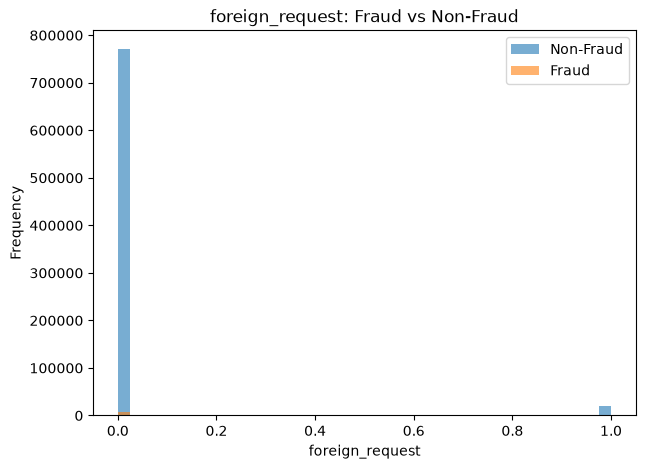

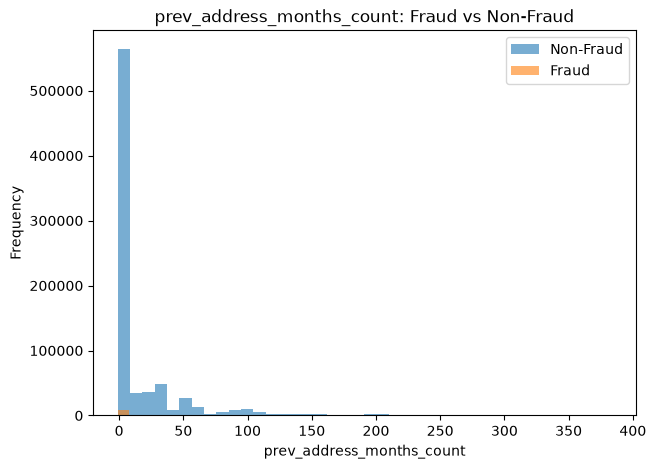

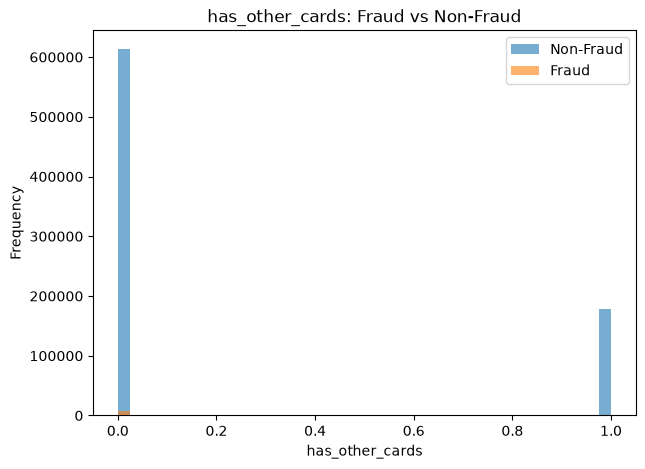

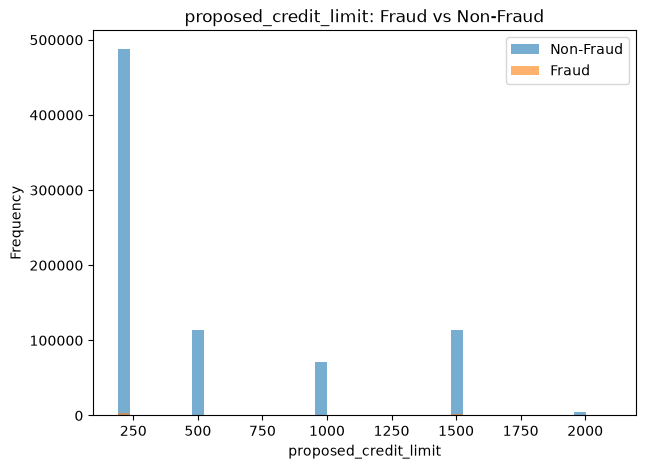

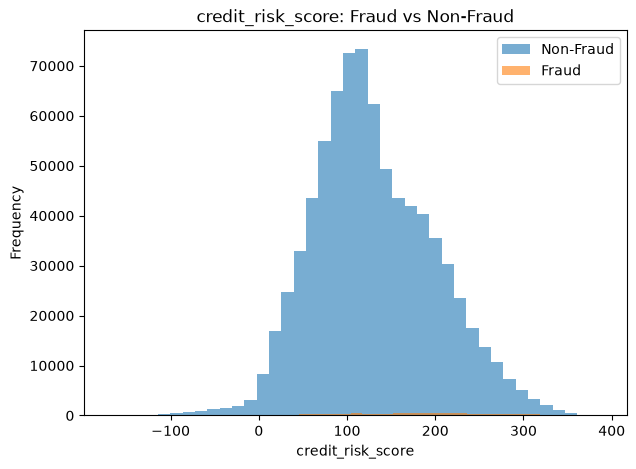

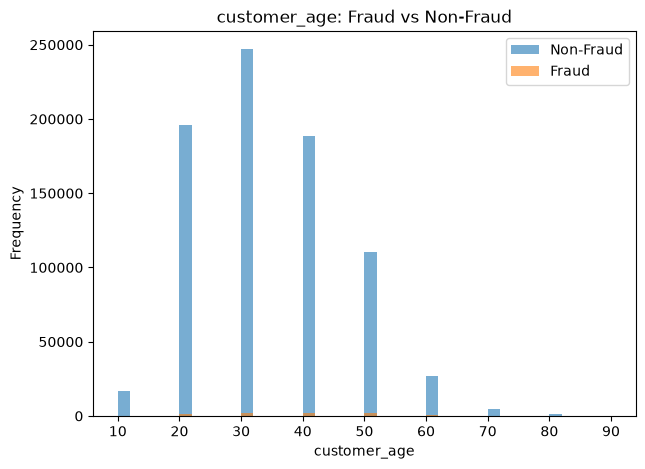

In [71]:
# ============================================================
# Day 3 - Step 6: Numerical Feature Distribution
# ============================================================

import matplotlib.pyplot as plt

selected_features = [
    "foreign_request",
    "prev_address_months_count",
    "has_other_cards",
    "proposed_credit_limit",
    "credit_risk_score",
    "customer_age"
]

for col in selected_features:
    plt.figure(figsize=(7, 5))

    plt.hist(
        X_train.loc[y_train == 0, col],
        bins=40,
        alpha=0.6,
        label="Non-Fraud"
    )

    plt.hist(
        X_train.loc[y_train == 1, col],
        bins=40,
        alpha=0.6,
        label="Fraud"
    )

    plt.title(f"{col}: Fraud vs Non-Fraud")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

In [72]:
# ============================================================
# Day 3 - Step 7: Numerical Feature Fraud-Rate Comparison
# ============================================================

numerical_fraud_summary = []

for col in numerical_features:
    fraud_mean = X_train.loc[y_train == 1, col].mean()
    non_fraud_mean = X_train.loc[y_train == 0, col].mean()

    numerical_fraud_summary.append({
        "feature": col,
        "non_fraud_mean": non_fraud_mean,
        "fraud_mean": fraud_mean,
        "absolute_difference": abs(fraud_mean - non_fraud_mean)
    })

numerical_fraud_summary_df = pd.DataFrame(
    numerical_fraud_summary
).sort_values(
    "absolute_difference",
    ascending=False
)

print("Numerical features with largest mean differences:")
print(
    numerical_fraud_summary_df.head(15).round(3).to_string(index=False)
)

Numerical features with largest mean differences:
                         feature  non_fraud_mean  fraud_mean  absolute_difference
                     velocity_6h        5669.471    5175.271              494.200
           proposed_credit_limit         512.591     829.931              317.340
                    velocity_24h        4771.963    4615.241              156.722
                     velocity_4w        4857.164    4751.984              105.180
                    zip_count_4w        1572.144    1628.531               56.387
            bank_branch_count_8w         184.875     132.883               51.992
               credit_risk_score         130.496     177.553               47.057
    current_address_months_count          86.307     114.170               27.863
       prev_address_months_count          16.821       5.946               10.875
                    customer_age          33.620      40.910                7.290
          intended_balcon_amount           8.718

In [73]:
# ============================================================
# Day 3 - Step 8: Numerical Outlier Check
# ============================================================

outlier_summary = []

for col in numerical_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (X_train[col] < lower_bound) |
        (X_train[col] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(X_train)
    ) * 100

    outlier_summary.append({
        "feature": col,
        "outlier_count": int(outlier_count),
        "outlier_percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(
    outlier_summary
).sort_values(
    "outlier_percentage",
    ascending=False
)

print("Numerical feature outlier summary:")
print(
    outlier_summary_df.round(2).to_string(index=False)
)

Numerical feature outlier summary:
                         feature  outlier_count  outlier_percentage
           proposed_credit_limit         193536               24.19
                 has_other_cards         178181               22.27
          intended_balcon_amount         177504               22.19
            bank_branch_count_8w         140220               17.53
       prev_address_months_count         125835               15.73
              phone_mobile_valid          88475               11.06
              days_since_request          75888                9.49
       session_length_in_minutes          63111                7.89
                    zip_count_4w          47882                5.99
    current_address_months_count          32753                4.09
       device_distinct_emails_8w          25581                3.20
                 foreign_request          20250                2.53
date_of_birth_distinct_emails_4w           7829                0.98
             

In [74]:
# ============================================================
# Day 3 - Step 9: Fraud Rate for Extreme Numerical Values
# ============================================================

selected_outlier_features = [
    "proposed_credit_limit",
    "intended_balcon_amount",
    "bank_branch_count_8w",
    "prev_address_months_count",
    "velocity_6h",
    "credit_risk_score"
]

for col in selected_outlier_features:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (X_train[col] < lower_bound) |
        (X_train[col] > upper_bound)
    )

    normal_mask = ~outlier_mask

    outlier_fraud_rate = y_train[outlier_mask].mean() * 100
    normal_fraud_rate = y_train[normal_mask].mean() * 100

    print(f"\nFeature: {col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Extreme-value records: {outlier_mask.sum():,}")
    print(f"Fraud rate (extreme): {outlier_fraud_rate:.2f}%")
    print(f"Fraud rate (normal):  {normal_fraud_rate:.2f}%")


Feature: proposed_credit_limit
Lower bound: -250.00
Upper bound: 950.00
Extreme-value records: 193,536
Fraud rate (extreme): 2.10%
Fraud rate (normal):  0.79%

Feature: intended_balcon_amount
Lower bound: -10.57
Upper bound: 14.46
Extreme-value records: 177,504
Fraud rate (extreme): 0.51%
Fraud rate (normal):  1.27%

Feature: bank_branch_count_8w
Lower bound: -35.00
Upper bound: 61.00
Extreme-value records: 140,220
Fraud rate (extreme): 0.74%
Fraud rate (normal):  1.18%

Feature: prev_address_months_count
Lower bound: -20.50
Upper bound: 31.50
Extreme-value records: 125,835
Fraud rate (extreme): 0.37%
Fraud rate (normal):  1.24%

Feature: velocity_6h
Lower bound: -2934.59
Upper bound: 14050.34
Extreme-value records: 7,184
Fraud rate (extreme): 0.78%
Fraud rate (normal):  1.11%

Feature: credit_risk_score
Lower bound: -59.50
Upper bound: 320.50
Extreme-value records: 6,986
Fraud rate (extreme): 3.95%
Fraud rate (normal):  1.08%


In [75]:
# ============================================================
# Day 3 - Step 10: Numerical Feature Correlation
# ============================================================

correlation_matrix = X_train[numerical_features].corr()

# Get upper triangle only to avoid duplicate pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

print("Top numerical feature correlations:")
print(
    correlation_pairs.head(15).round(3).to_string(index=False)
)

Top numerical feature correlations:
                       feature_1                        feature_2  correlation  absolute_correlation
                     velocity_4w                            month       -0.848                 0.848
               credit_risk_score            proposed_credit_limit        0.605                 0.605
                    velocity_24h                            month       -0.550                 0.550
                    velocity_24h                      velocity_4w        0.539                 0.539
                     velocity_6h                     velocity_24h        0.464                 0.464
                    customer_age date_of_birth_distinct_emails_4w       -0.421                 0.421
                     velocity_6h                            month       -0.409                 0.409
                     velocity_6h                      velocity_4w        0.400                 0.400
                    zip_count_4w                      v

In [76]:
# ============================================================
# Day 3 - Step 11: Numerical Features vs Fraud Correlation
# ============================================================

target_correlation = (
    X_train[numerical_features]
    .corrwith(y_train)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Numerical feature correlation with fraud_bool:")
print(target_correlation.round(4).to_string())

Numerical feature correlation with fraud_bool:
credit_risk_score                   0.0705
proposed_credit_limit               0.0680
customer_age                        0.0633
keep_alive_session                 -0.0504
income                              0.0452
date_of_birth_distinct_emails_4w   -0.0435
name_email_similarity              -0.0365
has_other_cards                    -0.0355
phone_home_valid                   -0.0347
device_distinct_emails_8w           0.0345
current_address_months_count        0.0329
email_is_free                       0.0274
prev_address_months_count          -0.0258
intended_balcon_amount             -0.0248
foreign_request                     0.0177
velocity_6h                        -0.0171
phone_mobile_valid                 -0.0136
month                               0.0133
velocity_4w                        -0.0119
bank_branch_count_8w               -0.0118
velocity_24h                       -0.0111
session_length_in_minutes           0.0076
zip_cou

In [77]:
# ============================================================
# Day 3 - Step 12: Binary Feature Fraud Rates
# ============================================================

binary_features = [
    col for col in numerical_features
    if X_train[col].nunique() == 2
]

binary_summary = []

for col in binary_features:

    grouped = (
        pd.DataFrame({
            "value": X_train[col],
            "fraud": y_train.values
        })
        .groupby("value")["fraud"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    for _, row in grouped.iterrows():
        binary_summary.append({
            "feature": col,
            "value": row["value"],
            "records": int(row["count"]),
            "fraud_cases": int(row["sum"]),
            "fraud_rate_%": row["mean"] * 100
        })

binary_summary_df = pd.DataFrame(binary_summary)

print("Binary numerical features:")
print(binary_features)

print("\nFraud rate by binary feature:")
print(
    binary_summary_df
    .sort_values(["feature", "value"])
    .round(2)
    .to_string(index=False)
)

Binary numerical features:
['email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards', 'foreign_request', 'keep_alive_session']

Fraud rate by binary feature:
           feature  value  records  fraud_cases  fraud_rate_%
     email_is_free    0.0   375946         3003          0.80
     email_is_free    1.0   424054         5820          1.37
   foreign_request    0.0   779750         8368          1.07
   foreign_request    1.0    20250          455          2.25
   has_other_cards    0.0   621819         8093          1.30
   has_other_cards    1.0   178181          730          0.41
keep_alive_session    0.0   338245         5811          1.72
keep_alive_session    1.0   461755         3012          0.65
  phone_home_valid    0.0   466206         6573          1.41
  phone_home_valid    1.0   333794         2250          0.67
phone_mobile_valid    0.0    88475         1332          1.51
phone_mobile_valid    1.0   711525         7491          1.05


In [78]:
# ============================================================
# Day 3 - Step 13: Potentially Informative Numerical Features
# ============================================================

feature_signal_summary = pd.DataFrame({
    "feature": target_correlation.index,
    "fraud_correlation": target_correlation.values,
})

feature_signal_summary["absolute_correlation"] = (
    feature_signal_summary["fraud_correlation"].abs()
)

feature_signal_summary = feature_signal_summary.sort_values(
    "absolute_correlation",
    ascending=False
)

print("Numerical features ranked by absolute correlation with fraud:")
print(
    feature_signal_summary.round(4).to_string(index=False)
)

print("\nTop 10 potentially informative numerical features:")

print(
    feature_signal_summary
    .head(10)
    .round(4)
    .to_string(index=False)
)

Numerical features ranked by absolute correlation with fraud:
                         feature  fraud_correlation  absolute_correlation
               credit_risk_score             0.0705                0.0705
           proposed_credit_limit             0.0680                0.0680
                    customer_age             0.0633                0.0633
              keep_alive_session            -0.0504                0.0504
                          income             0.0452                0.0452
date_of_birth_distinct_emails_4w            -0.0435                0.0435
           name_email_similarity            -0.0365                0.0365
                 has_other_cards            -0.0355                0.0355
                phone_home_valid            -0.0347                0.0347
       device_distinct_emails_8w             0.0345                0.0345
    current_address_months_count             0.0329                0.0329
                   email_is_free             0.027

In [79]:
# ============================================================
# Day 3 - Step 14: Sentinel (-1) Value Analysis
# ============================================================

sentinel_summary = []

for col in minus_one_features:

    sentinel_mask = X_train[col] == -1

    sentinel_summary.append({
        "feature": col,
        "minus_one_records": int(sentinel_mask.sum()),
        "minus_one_percentage": (
            sentinel_mask.mean() * 100
        ),
        "fraud_rate_minus_one": (
            y_train[sentinel_mask].mean() * 100
        ),
        "fraud_rate_other_values": (
            y_train[~sentinel_mask].mean() * 100
        )
    })

sentinel_summary_df = pd.DataFrame(
    sentinel_summary
).sort_values(
    "minus_one_percentage",
    ascending=False
)

print("Sentinel (-1) value analysis:")
print(
    sentinel_summary_df.round(2).to_string(index=False)
)

Sentinel (-1) value analysis:
                     feature  minus_one_records  minus_one_percentage  fraud_rate_minus_one  fraud_rate_other_values
   prev_address_months_count             570525                 71.32                  1.42                     0.32
           bank_months_count             202604                 25.33                  1.63                     0.92
current_address_months_count               3391                  0.42                  0.29                     1.11
   session_length_in_minutes               1623                  0.20                  0.99                     1.10
           credit_risk_score                388                  0.05                  0.00                     1.10
   device_distinct_emails_8w                290                  0.04                  1.38                     1.10


In [80]:
# ============================================================
# Day 3 - Step 15: Final EDA Feature Summary
# ============================================================

print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\n1. TARGET DISTRIBUTION")
print("-" * 70)
print(f"Non-Fraud: {y_train.eq(0).sum():,} "
      f"({y_train.eq(0).mean() * 100:.2f}%)")
print(f"Fraud:     {y_train.eq(1).sum():,} "
      f"({y_train.eq(1).mean() * 100:.2f}%)")

print("\n2. TOP NUMERICAL FEATURES BY TARGET CORRELATION")
print("-" * 70)

print(
    feature_signal_summary
    .head(10)
    [["feature", "fraud_correlation"]]
    .round(4)
    .to_string(index=False)
)

print("\n3. BINARY FEATURES WITH HIGHEST FRAUD RATE")
print("-" * 70)

binary_highest = (
    binary_summary_df
    .sort_values("fraud_rate_%", ascending=False)
    .head(6)
)

print(
    binary_highest[
        ["feature", "value", "records", "fraud_cases", "fraud_rate_%"]
    ]
    .round(2)
    .to_string(index=False)
)

print("\n4. SENTINEL (-1) VALUES")
print("-" * 70)

print(
    sentinel_summary_df[
        [
            "feature",
            "minus_one_percentage",
            "fraud_rate_minus_one",
            "fraud_rate_other_values"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

print("\n5. DATA QUALITY DECISIONS")
print("-" * 70)
print("Missing values: None")
print("Duplicate rows: None")
print("Constant feature removed: device_fraud_count")
print("Outliers: Retained")
print("-1 sentinel values: Retained")
print("Categorical features: One-hot encoded")
print("Train/Test split: Stratified 80/20")

FINAL EDA SUMMARY

1. TARGET DISTRIBUTION
----------------------------------------------------------------------
Non-Fraud: 791,177 (98.90%)
Fraud:     8,823 (1.10%)

2. TOP NUMERICAL FEATURES BY TARGET CORRELATION
----------------------------------------------------------------------
                         feature  fraud_correlation
               credit_risk_score             0.0705
           proposed_credit_limit             0.0680
                    customer_age             0.0633
              keep_alive_session            -0.0504
                          income             0.0452
date_of_birth_distinct_emails_4w            -0.0435
           name_email_similarity            -0.0365
                 has_other_cards            -0.0355
                phone_home_valid            -0.0347
       device_distinct_emails_8w             0.0345

3. BINARY FEATURES WITH HIGHEST FRAUD RATE
----------------------------------------------------------------------
           feature  value  